# Lab 9: Mapping

This notebook implements a **step-and-stop, right-ToF-only, dual-pass dense P-only mapping scan** for Lab 9.

Workflow:
- configure ToF mode and orientation PID gains
- run one scan at a time with `MAP_START`
- retrieve `target angle + measured DMP heading + ToF distance`
- sanity-check each scan in polar coordinates
- transform all scans into the room frame and build a global scatter map
- export a manual line-based map for later labs


## 1. Setup and Imports

In [7]:
import sys
sys.path.append('..')

import time
import math
import pickle
import importlib
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ble import get_ble_controller
from base_ble import LOG
import cmd_types
importlib.reload(cmd_types)
from cmd_types import CMD

%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 5]
plt.rcParams['font.size'] = 12

print('Imports done.')


Imports done.


## 2. Connect to Artemis via BLE

In [8]:
ble = get_ble_controller()
ble.connect()
print('Connected!')

def ble_reconnect():
    global ble
    print('Reconnecting BLE ...')
    try:
        ble.disconnect()
    except Exception:
        pass
    time.sleep(1.0)
    ble = get_ble_controller()
    ble.connect()
    print('Reconnected!')


2026-04-08 09:35:41,887 | INFO     |: Already connected to a BLE device
Connected!


## 3. Parameters

Defaults below are set for a **dense right-sensor dual-pass scan**. Sweep is defined as `380 deg` to compensate for static friction at the end of the turn.

In [9]:
# Mapping controller (dense right-sensor scan defaults)
SWEEP_DEG = 380
STEP_DEG = 3
SAMPLES_GOAL = math.ceil(SWEEP_DEG / STEP_DEG)
MAP_TIMEOUT_MS = 120000

# P-only turning for dense step-and-stop scans.
# We log the measured heading, so small steady-state error is acceptable.
ORIENT_KP = 2.0
ORIENT_KI = 0.0
ORIENT_KD = 0.0

# ToF mode: 0 = short, 1 = long
TOF_MODE = 1
ACTIVE_SENSOR = 'right'
TURN_DIR_CW = 1
TURN_DIR_CCW = -1

# Unit conversion
MM_PER_FT = 304.8

# Sensor mounting assumptions in robot body frame (ft).
# x = forward, y = left. Mapping defaults below use the right sensor only.
FRONT_SENSOR_OFFSET_FT = np.array([0.0, 0.0])
RIGHT_SENSOR_OFFSET_FT = np.array([0.0, 0.0])
FRONT_SENSOR_YAW_DEG = 0.0
RIGHT_SENSOR_YAW_DEG = -90.0
ROBOT_YAW_OFFSET_DEG = 0.0

# Global point-cloud range filter.
# Keep points only if the measured hit distance is within a reasonable room-scale range.
MIN_VALID_RANGE_FT = 0.15
MAX_VALID_RANGE_FT = 12.0

# Optional dense-cloud filter. Keep disabled by default for sparse Lab 9 maps.
OUTLIER_RADIUS_FT = 0.35
OUTLIER_MIN_NEIGHBORS = 2

# Scan positions for this run, in room frame (ft).
# Keep theta0_deg the same for every scan if you always start with the same heading.
SCAN_POSES_FT = {
    'scan_5_-3':  {'x_ft':  5.0, 'y_ft': -3.0, 'theta0_deg': 0.0, 'dx_ft': 0.0, 'dy_ft': 0.0, 'dtheta_deg': 0.0},
    'scan_0_0':   {'x_ft':  0.0, 'y_ft':  0.0, 'theta0_deg': 0.0, 'dx_ft': 0.0, 'dy_ft': 0.0, 'dtheta_deg': 0.0},
    'scan_-3_2':  {'x_ft': -3.0, 'y_ft':  2.0, 'theta0_deg': 0.0, 'dx_ft': 0.0, 'dy_ft': 0.0, 'dtheta_deg': 0.0},
    'scan_0_3':   {'x_ft':  0.0, 'y_ft':  3.0, 'theta0_deg': 0.0, 'dx_ft': 0.0, 'dy_ft': 0.0, 'dtheta_deg': 0.0},
    'scan_5_3':   {'x_ft':  5.0, 'y_ft':  3.0, 'theta0_deg': 0.0, 'dx_ft': 0.0, 'dy_ft': 0.0, 'dtheta_deg': 0.0},
}

# Map cleanup after global transform.
MAX_POINTS_FROM_SCAN_FT = 6.0

DATA_PATH = Path('lab9_map_runs.pkl')
SNAPSHOT_DIR = Path('lab9_map_run_snapshots')
DATA_FORMAT_VERSION = 2
SAVE_TIMESTAMPED_BACKUP = True
SAVE_PER_RUN_SNAPSHOT = True
DEFAULT_PASS_SPECS = [
    ('pass_a_cw', TURN_DIR_CW),
    ('pass_b_ccw', TURN_DIR_CCW),
]

# Notebook collection mode for users who prefer Run All.
# Set COLLECTION_MODE = 'single' to collect one run, or 'batch' to walk through multiple locations.
COLLECTION_MODE = 'batch'
AUTO_LOAD_EXISTING = True
AUTO_SAVE_AFTER_EACH_SCAN = True
SKIP_EXISTING_RUNS = True

# Single-run mode
SINGLE_SCAN_KEY = 'scan_5_-3'
SINGLE_PASS_NAME = 'tune_cw'
SINGLE_TURN_DIR = TURN_DIR_CW

# Batch mode: 5 locations x 2 passes = 10 runs total.
BATCH_SCAN_KEYS = ['scan_5_-3', 'scan_0_0', 'scan_-3_2', 'scan_0_3', 'scan_5_3']
BATCH_PASS_SPECS = DEFAULT_PASS_SPECS

# Safety: set False if you want Run All to stop before collecting data.
ENABLE_COLLECTION = True

print(f'Sensor = {ACTIVE_SENSOR}, sweep = {SWEEP_DEG} deg, step = {STEP_DEG} deg, samples = {SAMPLES_GOAL}, timeout = {MAP_TIMEOUT_MS} ms')


Sensor = right, sweep = 380 deg, step = 3 deg, samples = 127, timeout = 120000 ms


## 4. BLE Helpers

In [10]:
def ping():
    ble.send_command(CMD.PING, '')
    time.sleep(0.10)
    return ble.receive_string(ble.uuid['RX_STRING'])

def set_tof_mode(mode=TOF_MODE):
    ble.send_command(CMD.SET_TOF_MODE, f'{mode}')
    time.sleep(0.15)
    resp = ble.receive_string(ble.uuid['RX_STRING'])
    print(f'ToF mode -> {resp}')
    return resp

def get_tof_once():
    ble.send_command(CMD.GET_TOF_DATA, '')
    time.sleep(0.15)
    resp = ble.receive_string(ble.uuid['RX_STRING'])
    print(f'GET_TOF_DATA -> {resp}')
    return resp

def set_orient_gains(kp=ORIENT_KP, ki=ORIENT_KI, kd=ORIENT_KD):
    ble.send_command(CMD.SET_ORIENT_GAINS, f'{kp}|{ki}|{kd}')
    time.sleep(0.15)
    resp = ble.receive_string(ble.uuid['RX_STRING'])
    print(f'Orientation gains -> {resp}')
    return resp

def set_map_params(step_deg=STEP_DEG, samples_goal=SAMPLES_GOAL,
                   timeout_ms=MAP_TIMEOUT_MS, turn_dir=TURN_DIR_CW,
                   sweep_deg=SWEEP_DEG):
    ble.send_command(CMD.SET_MAP_PARAMS, f'{step_deg}|{samples_goal}|{timeout_ms}|{turn_dir}|{sweep_deg}')
    time.sleep(0.15)
    resp = ble.receive_string(ble.uuid['RX_STRING'])
    print(f'Map params -> {resp}')
    return resp

def get_map_status():
    ble.send_command(CMD.GET_MAP_STATUS, '')
    time.sleep(0.05)
    resp = ble.receive_string(ble.uuid['RX_STRING'])
    print(f'MAP_STATUS -> {resp}')
    return resp

def map_stop():
    ble.send_command(CMD.MAP_STOP, '')
    time.sleep(0.10)
    try:
        print(ble.receive_string(ble.uuid['RX_STRING']))
    except Exception as ex:
        print(f'MAP_STOP ack read failed: {ex}')

print('Low-level BLE helpers defined.')


Low-level BLE helpers defined.


## 5. Mapping Scan Helpers

Firmware returns rows in the format:

`MAP|target_x10|heading_x10|front_mm|right_mm|timestamp_ms`

In [11]:
_map_buf = []
_map_done = False

def map_notify_handler(uuid, bytearray_data):
    global _map_buf, _map_done
    try:
        msg = ble.bytearray_to_string(bytearray_data).strip()
        _map_buf.append(msg)
        if msg.startswith('MAP_END|'):
            _map_done = True
    except Exception as ex:
        print(f'Handler error: {ex}')

def parse_map_messages(messages, scan_name='scan', turn_dir=TURN_DIR_CW, pass_name='pass'):
    rows = []
    ctrl = []
    for msg in messages:
        if msg.startswith('MAP|'):
            parts = msg.split('|')
            if len(parts) == 6:
                rows.append({
                    'scan_name': scan_name,
                    'target_deg': int(parts[1]) / 10.0,
                    'heading_deg': int(parts[2]) / 10.0,
                    'front_mm': int(parts[3]),
                    'right_mm': int(parts[4]),
                    'time_ms': int(parts[5]),
                    'turn_dir': turn_dir,
                    'pass_name': pass_name,
                })
        else:
            ctrl.append(msg)

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values('time_ms').reset_index(drop=True)
        df['time_s'] = (df['time_ms'] - df['time_ms'].iloc[0]) / 1000.0
        df['front_valid'] = df['front_mm'] > 0
        df['right_valid'] = df['right_mm'] > 0
        df['front_ft'] = np.where(df['front_valid'], df['front_mm'] / MM_PER_FT, np.nan)
        df['right_ft'] = np.where(df['right_valid'], df['right_mm'] / MM_PER_FT, np.nan)
        df['heading_err_deg'] = ((df['heading_deg'] - df['target_deg'] + 180.0) % 360.0) - 180.0
        diffs = df['heading_deg'].diff().abs()
        df['heading_step_deg'] = diffs.fillna(0.0)
    return df, ctrl

def summarize_map_scan(df, ctrl_msgs=None):
    if df.empty:
        print('No map rows received.')
        if ctrl_msgs:
            print('Control messages:', ctrl_msgs)
        return

    valid_right = int(df['right_valid'].sum())
    err = df['heading_err_deg'].abs()
    print(f'Samples: {len(df)}')
    print(f'Valid right ToF: {valid_right}/{len(df)}')
    print(f'Mean |heading error|: {err.mean():.2f} deg')
    print(f'Max  |heading error|: {err.max():.2f} deg')
    if len(df) > 1:
        spacing = df['target_deg'].diff().dropna()
        print(f'Target spacing: mean {spacing.mean():.2f} deg, min {spacing.min():.2f}, max {spacing.max():.2f}')
    if ctrl_msgs:
        print('Control messages:', ctrl_msgs[-6:])

def parse_map_status(msg):
    parts = msg.split('|')
    if len(parts) != 9 or parts[0] != 'MAP_STATUS':
        raise ValueError(f'Unexpected MAP_STATUS: {msg}')
    return {
        'state': parts[1],
        'sample_idx': int(parts[2]),
        'log_pos': int(parts[3]),
        'phase': int(parts[4]),
        'start_ms': int(parts[5]),
        'now_ms': int(parts[6]),
        'sweep_deg': int(parts[7]),
        'step_deg': int(parts[8]),
    }

def run_map_scan(scan_name, step_deg=STEP_DEG, samples_goal=SAMPLES_GOAL,
                 timeout_ms=MAP_TIMEOUT_MS, turn_dir=TURN_DIR_CW,
                 pass_name='pass', sweep_deg=SWEEP_DEG, fetch_timeout_s=30.0,
                 status_poll_s=0.25):
    global _map_buf, _map_done
    _map_buf = []
    _map_done = False

    try:
        ble.stop_notify(ble.uuid['RX_STRING'])
    except Exception:
        pass

    ble.start_notify(ble.uuid['RX_STRING'], map_notify_handler)
    time.sleep(0.05)

    timing = {}
    scan_t0 = time.time()
    ble.send_command(CMD.MAP_START, f'{step_deg}|{samples_goal}|{timeout_ms}|{turn_dir}|{sweep_deg}')
    wait_deadline = time.time() + timeout_ms / 1000.0 + 3.0
    last_status = None
    while time.time() < wait_deadline:
        if any(msg.startswith('MAP_DONE|') or msg.startswith('MAP_TIMEOUT') for msg in _map_buf):
            break
        ble.send_command(CMD.GET_MAP_STATUS, '')
        time.sleep(0.05)
        try:
            status_msg = ble.receive_string(ble.uuid['RX_STRING'])
            last_status = parse_map_status(status_msg)
            if last_status['state'] == 'IDLE':
                break
        except Exception:
            pass
        time.sleep(status_poll_s)
    timing['scan_wall_s'] = time.time() - scan_t0

    transfer_t0 = time.time()
    ble.send_command(CMD.GET_MAP_DATA, '')
    t0 = time.time()
    while not _map_done and (time.time() - t0 < fetch_timeout_s):
        time.sleep(0.10)
    timing['transfer_wall_s'] = time.time() - transfer_t0

    try:
        ble.stop_notify(ble.uuid['RX_STRING'])
    except Exception:
        pass

    parse_t0 = time.time()
    df, ctrl_msgs = parse_map_messages(_map_buf, scan_name=scan_name,
                                      turn_dir=turn_dir, pass_name=pass_name)
    timing['parse_wall_s'] = time.time() - parse_t0
    summarize_map_scan(df, ctrl_msgs)
    print(f"Timing: scan={timing['scan_wall_s']:.2f}s transfer={timing['transfer_wall_s']:.2f}s parse={timing['parse_wall_s']:.2f}s")
    return df, list(_map_buf), ctrl_msgs, timing, last_status

print('Mapping helpers defined.')


Mapping helpers defined.


## 6. Run Management

Use a single tuning run first. The default flow for each marked location is now two independent 380 degree scans: one CW (clockwise) and one CCW (counterclockwise). Re-center the robot on the floor mark between passes to limit position drift.

In [12]:
scan_runs = {}

def _now_utc_iso():
    return datetime.now(timezone.utc).isoformat()

def build_session_metadata():
    return {
        'format_version': DATA_FORMAT_VERSION,
        'saved_at_utc': _now_utc_iso(),
        'active_sensor': ACTIVE_SENSOR,
        'tof_mode': TOF_MODE,
        'sweep_deg': SWEEP_DEG,
        'step_deg': STEP_DEG,
        'samples_goal': SAMPLES_GOAL,
        'map_timeout_ms': MAP_TIMEOUT_MS,
        'default_pass_specs': list(DEFAULT_PASS_SPECS),
        'batch_scan_keys': list(BATCH_SCAN_KEYS),
        'scan_poses_ft': {k: dict(v) for k, v in SCAN_POSES_FT.items()},
        'filters': {
            'min_valid_range_ft': MIN_VALID_RANGE_FT,
            'max_valid_range_ft': MAX_VALID_RANGE_FT,
            'max_points_from_scan_ft': MAX_POINTS_FROM_SCAN_FT,
            'outlier_radius_ft': OUTLIER_RADIUS_FT,
            'outlier_min_neighbors': OUTLIER_MIN_NEIGHBORS,
        },
        'sensor_mount': {
            'front_sensor_offset_ft': FRONT_SENSOR_OFFSET_FT.tolist(),
            'right_sensor_offset_ft': RIGHT_SENSOR_OFFSET_FT.tolist(),
            'front_sensor_yaw_deg': FRONT_SENSOR_YAW_DEG,
            'right_sensor_yaw_deg': RIGHT_SENSOR_YAW_DEG,
            'robot_yaw_offset_deg': ROBOT_YAW_OFFSET_DEG,
        },
    }

def serialize_scan_entry(name, entry):
    df = entry['df']
    valid_col = f'{ACTIVE_SENSOR}_valid'
    valid_samples = int(df[valid_col].sum()) if valid_col in df.columns else 0
    return {
        'pose': dict(entry['pose']),
        'ctrl': list(entry['ctrl']),
        'raw': list(entry['raw']),
        'turn_dir': entry['turn_dir'],
        'pass_name': entry['pass_name'],
        'timing': dict(entry.get('timing', {})),
        'last_status': entry.get('last_status'),
        'meta': dict(entry.get('meta', {})),
        'sample_count': int(len(df)),
        'valid_sample_count': valid_samples,
        'df': df.to_dict(orient='list'),
    }

def build_scan_payload():
    runs = {}
    for name, entry in scan_runs.items():
        runs[name] = serialize_scan_entry(name, entry)
    return {
        'meta': build_session_metadata(),
        'runs': runs,
    }

def atomic_pickle_dump(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp_path = path.with_suffix(path.suffix + '.tmp')
    with open(tmp_path, 'wb') as f:
        pickle.dump(obj, f)
    tmp_path.replace(path)

def save_scan_runs(path=DATA_PATH, saved_run_name=None):
    payload = build_scan_payload()
    atomic_pickle_dump(payload, path)

    extra_paths = []
    if SAVE_TIMESTAMPED_BACKUP and saved_run_name is not None:
        stamp = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')
        backup_path = Path(path).with_name(f"{Path(path).stem}_{saved_run_name}_{stamp}.pkl")
        atomic_pickle_dump(payload, backup_path)
        extra_paths.append(str(backup_path))

    if SAVE_PER_RUN_SNAPSHOT and saved_run_name is not None and saved_run_name in payload['runs']:
        SNAPSHOT_DIR.mkdir(parents=True, exist_ok=True)
        snapshot_path = SNAPSHOT_DIR / f'{saved_run_name}.pkl'
        atomic_pickle_dump({
            'meta': payload['meta'],
            'run_name': saved_run_name,
            'run': payload['runs'][saved_run_name],
        }, snapshot_path)
        extra_paths.append(str(snapshot_path))

    print(f"Saved {len(payload['runs'])} scans -> {Path(path).resolve()}")
    for extra_path in extra_paths:
        print(f'  backup -> {extra_path}')

def load_scan_runs_if_exists(path=DATA_PATH):
    global scan_runs
    if not Path(path).exists():
        print(f'No existing run file at {path}; starting fresh.')
        scan_runs = {}
        return
    load_scan_runs(path)

def load_scan_runs(path=DATA_PATH):
    global scan_runs
    with open(path, 'rb') as f:
        payload = pickle.load(f)

    if isinstance(payload, dict) and 'runs' in payload:
        runs_payload = payload['runs']
        file_meta = payload.get('meta', {})
    else:
        runs_payload = payload
        file_meta = {}

    scan_runs = {}
    for name, entry in runs_payload.items():
        scan_runs[name] = {
            'pose': entry['pose'],
            'ctrl': entry['ctrl'],
            'raw': entry['raw'],
            'turn_dir': entry.get('turn_dir', TURN_DIR_CW),
            'pass_name': entry.get('pass_name', 'pass'),
            'timing': entry.get('timing', {}),
            'last_status': entry.get('last_status'),
            'meta': entry.get('meta', {}),
            'df': pd.DataFrame(entry['df']),
        }
    fmt = file_meta.get('format_version', 1)
    print(f'Loaded {len(scan_runs)} scans from {path} (format v{fmt})')

def run_named_scan(scan_key, pass_name='pass_a_cw', turn_dir=TURN_DIR_CW,
                   step_deg=STEP_DEG, samples_goal=SAMPLES_GOAL,
                   timeout_ms=MAP_TIMEOUT_MS, prompt=True):
    pose = dict(SCAN_POSES_FT[scan_key])
    run_name = f'{scan_key}_{pass_name}'
    if prompt:
        direction = 'CW' if turn_dir > 0 else 'CCW'
        if pass_name == 'pass_b_ccw':
            input(
                f"Re-center robot at {scan_key}, align it to the same reference heading, then press Enter for {direction} pass ..."
            )
        else:
            input(
                f"Place robot at {scan_key} = ({pose['x_ft']}, {pose['y_ft']}) ft, "
                f"facing theta0 = {pose['theta0_deg']} deg. Press Enter for {direction} pass ..."
            )
    df, raw, ctrl, timing, last_status = run_map_scan(run_name, step_deg=step_deg,
                                                     samples_goal=samples_goal,
                                                     timeout_ms=timeout_ms,
                                                     turn_dir=turn_dir,
                                                     pass_name=pass_name,
                                                     sweep_deg=SWEEP_DEG)
    scan_runs[run_name] = {
        'pose': pose,
        'ctrl': ctrl,
        'raw': raw,
        'turn_dir': turn_dir,
        'pass_name': pass_name,
        'timing': timing,
        'last_status': last_status,
        'meta': {
            'run_name': run_name,
            'scan_key': scan_key,
            'saved_at_utc': _now_utc_iso(),
            'turn_dir_label': 'CW' if turn_dir > 0 else 'CCW',
            'step_deg': step_deg,
            'samples_goal': samples_goal,
            'timeout_ms': timeout_ms,
            'sweep_deg': SWEEP_DEG,
            'active_sensor': ACTIVE_SENSOR,
            'tof_mode': TOF_MODE,
            'filters': {
                'min_valid_range_ft': MIN_VALID_RANGE_FT,
                'max_valid_range_ft': MAX_VALID_RANGE_FT,
                'max_points_from_scan_ft': MAX_POINTS_FROM_SCAN_FT,
            },
        },
        'df': df,
    }
    if AUTO_SAVE_AFTER_EACH_SCAN:
        save_scan_runs(saved_run_name=run_name)
    return df

def run_scan_pair(scan_key, pass_specs=DEFAULT_PASS_SPECS,
                  auto_save=AUTO_SAVE_AFTER_EACH_SCAN,
                  skip_existing=SKIP_EXISTING_RUNS):
    for pass_name, turn_dir in pass_specs:
        run_name = f'{scan_key}_{pass_name}'
        if skip_existing and run_name in scan_runs:
            print(f'\n=== {run_name} already exists; skipping ===')
            continue
        print(f'\n=== {scan_key} {pass_name} ===')
        run_named_scan(scan_key, pass_name=pass_name, turn_dir=turn_dir)
        if auto_save:
            save_scan_runs()

def run_required_scans(scan_keys=None, pass_specs=DEFAULT_PASS_SPECS,
                       auto_load=AUTO_LOAD_EXISTING,
                       auto_save=AUTO_SAVE_AFTER_EACH_SCAN,
                       skip_existing=SKIP_EXISTING_RUNS):
    if auto_load:
        load_scan_runs_if_exists()
    if scan_keys is None:
        scan_keys = list(SCAN_POSES_FT.keys())
    for scan_key in scan_keys:
        run_scan_pair(scan_key, pass_specs=pass_specs,
                      auto_save=auto_save,
                      skip_existing=skip_existing)
    print(f'Completed {len(scan_runs)} stored scans.')

def set_run_pose_correction(run_name, dx_ft=0.0, dy_ft=0.0, dtheta_deg=0.0):
    pose = scan_runs[run_name]['pose']
    pose['dx_ft'] = dx_ft
    pose['dy_ft'] = dy_ft
    pose['dtheta_deg'] = dtheta_deg
    print(f"Updated {run_name}: dx={dx_ft}, dy={dy_ft}, dtheta={dtheta_deg}")

def list_run_pose_corrections():
    rows = []
    for run_name, entry in scan_runs.items():
        pose = entry['pose']
        rows.append({
            'run_name': run_name,
            'dx_ft': pose.get('dx_ft', 0.0),
            'dy_ft': pose.get('dy_ft', 0.0),
            'dtheta_deg': pose.get('dtheta_deg', 0.0),
        })
    return pd.DataFrame(rows)


## 7. Configure the Robot

In [13]:
print('PING:', ping())
set_tof_mode(TOF_MODE)
set_orient_gains(ORIENT_KP, ORIENT_KI, ORIENT_KD)
set_map_params(STEP_DEG, SAMPLES_GOAL, MAP_TIMEOUT_MS, TURN_DIR_CW, SWEEP_DEG)
get_map_status()
get_tof_once()


PING: PONG
ToF mode -> TOF_MODE|LONG
Orientation gains -> ORIENT_GAINS|2.000|0.000|0.000
Map params -> MAP_PARAMS|step=3|samples=127|tout=120000|dir=1|sweep=380
MAP_STATUS -> MAP_STATUS|IDLE|127|127|2|947491|1468979|380|3
GET_TOF_DATA -> 2025|405


'2025|405'

## 8. Data Collection

This cell is designed for `Run All`. Set `COLLECTION_MODE` near the top of the notebook, then run all cells. The notebook will auto-load existing data if available and auto-save after each scan so you can move between positions without losing work.

In [14]:
df_tune = pd.DataFrame()

if AUTO_LOAD_EXISTING:
    load_scan_runs_if_exists()

if not ENABLE_COLLECTION:
    print('Collection disabled. Set ENABLE_COLLECTION = True to run scans.')
elif COLLECTION_MODE == 'single':
    print(f'Running single collection: {SINGLE_SCAN_KEY} / {SINGLE_PASS_NAME}')
    df_tune = run_named_scan(
        SINGLE_SCAN_KEY,
        pass_name=SINGLE_PASS_NAME,
        turn_dir=SINGLE_TURN_DIR,
    )
    if AUTO_SAVE_AFTER_EACH_SCAN:
        save_scan_runs()
elif COLLECTION_MODE == 'batch':
    print(f'Running batch collection for {BATCH_SCAN_KEYS}')
    run_required_scans(
        scan_keys=BATCH_SCAN_KEYS,
        pass_specs=BATCH_PASS_SPECS,
        auto_load=False,
        auto_save=AUTO_SAVE_AFTER_EACH_SCAN,
        skip_existing=SKIP_EXISTING_RUNS,
    )
    if AUTO_SAVE_AFTER_EACH_SCAN:
        save_scan_runs()
else:
    raise ValueError(f'Unknown COLLECTION_MODE: {COLLECTION_MODE}')

print(f'Currently stored runs: {list(scan_runs.keys())}')
if not df_tune.empty:
    df_tune.head()


Loaded 6 scans from lab9_map_runs.pkl (format v1)
Running batch collection for ['scan_5_-3', 'scan_0_0', 'scan_-3_2', 'scan_0_3', 'scan_5_3']

=== scan_5_-3 pass_a_cw ===
Samples: 127
Valid right ToF: 127/127
Mean |heading error|: 4.82 deg
Max  |heading error|: 10.10 deg
Target spacing: mean 3.00 deg, min 3.00, max 3.00
Control messages: ['MAP_STATUS|RUNNING|118|118|0|1470388|1485831|380|3', 'MAP_STATUS|RUNNING|122|122|1|1470388|1486226|380|3', 'MAP_STATUS|RUNNING|125|125|0|1470388|1486643|380|3', 'MAP_DONE|127', 'MAP_STATUS|IDLE|127|127|2|1470388|1487025|380|3', 'MAP_END|127']
Timing: scan=16.81s transfer=30.15s parse=0.01s
Saved 7 scans -> /Users/qiandaoliu/fastrobot/ble_robot_1.4/ble_python/lab9_map_runs.pkl
  backup -> lab9_map_runs_scan_5_-3_pass_a_cw_20260408T133632Z.pkl
  backup -> lab9_map_run_snapshots/scan_5_-3_pass_a_cw.pkl
Saved 7 scans -> /Users/qiandaoliu/fastrobot/ble_robot_1.4/ble_python/lab9_map_runs.pkl

=== scan_5_-3 pass_b_ccw ===
Samples: 127
Valid right ToF: 127/1

## 9. Collection Notes

Recommended use:
- `COLLECTION_MODE = 'single'` for one test run or one manually selected point
- `COLLECTION_MODE = 'batch'` for the required four-point sequence
- leave `AUTO_SAVE_AFTER_EACH_SCAN = True` so every finished pass is written to disk immediately
- leave `SKIP_EXISTING_RUNS = True` so `Run All` can safely resume from a partially completed session

In [15]:
print('Current run file:', DATA_PATH)
print('Saved runs:', list(scan_runs.keys()))


Current run file: lab9_map_runs.pkl
Saved runs: ['scan_-3_-2_tune_cw', 'scan_-3_-2_pass_a_cw', 'scan_-3_-2_pass_b_ccw', 'scan_5_3_pass_a_cw', 'scan_5_3_pass_b_ccw', 'scan_0_3_pass_a_cw', 'scan_5_-3_pass_a_cw', 'scan_5_-3_pass_b_ccw', 'scan_0_0_pass_a_cw', 'scan_0_0_pass_b_ccw', 'scan_-3_2_pass_a_cw', 'scan_-3_2_pass_b_ccw', 'scan_0_3_pass_b_ccw']


## 10. Polar Plot Sanity Check

In [16]:
def plot_polar_scan(df, title=''):
    if df.empty:
        print('No data to plot.')
        return

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='polar')
    right = df[df['right_valid']].copy()
    right_theta = np.deg2rad(right['heading_deg'] + RIGHT_SENSOR_YAW_DEG)
    ax.scatter(right_theta, right['right_ft'],
               s=20, c='tab:orange', label='Right ToF')

    ax.set_theta_zero_location('E')
    ax.set_theta_direction(1)
    ax.set_title(title or df['scan_name'].iloc[0])
    ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
    plt.show()

def plot_heading_error(df, title='Heading Error'):
    if df.empty:
        print('No data to plot.')
        return
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    axes[0].plot(df['time_s'], df['heading_deg'], 'o-', label='Measured heading')
    axes[0].plot(df['time_s'], df['target_deg'], 'k--', label='Target heading')
    axes[0].set_ylabel('Heading (deg)')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    axes[0].set_title(title)

    axes[1].plot(df['time_s'], df['heading_err_deg'], 'o-', color='tab:red')
    axes[1].axhline(0.0, color='k', lw=1)
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('Measured - target (deg)')
    axes[1].grid(alpha=0.3)
    plt.show()

# Example plots for the latest tuning scan.
plot_polar_scan(df_tune, title='Tuning Scan')
plot_heading_error(df_tune, title='Tuning Scan Heading Tracking')


No data to plot.
No data to plot.


## 11. Transform All Scans Into the Room Frame

Range filter: kept 1650/1651 points, removed 1
Scan-radius filter (6.0 ft): kept 1436/1650 points, removed 214


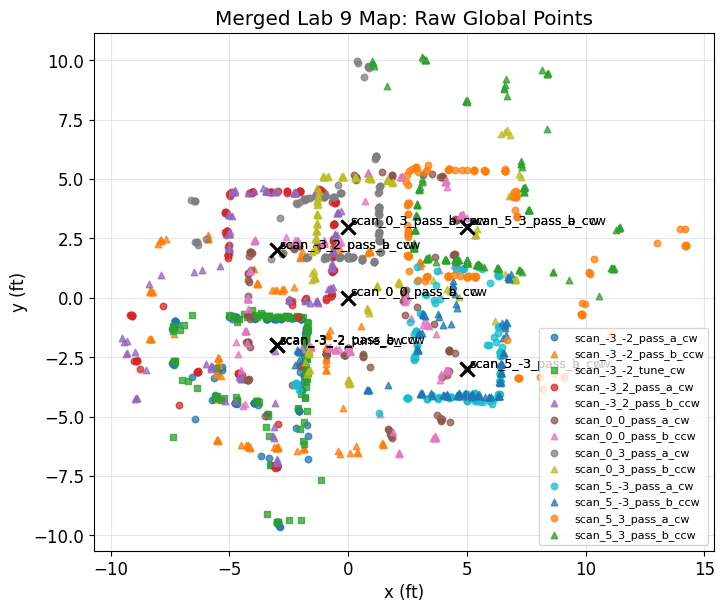

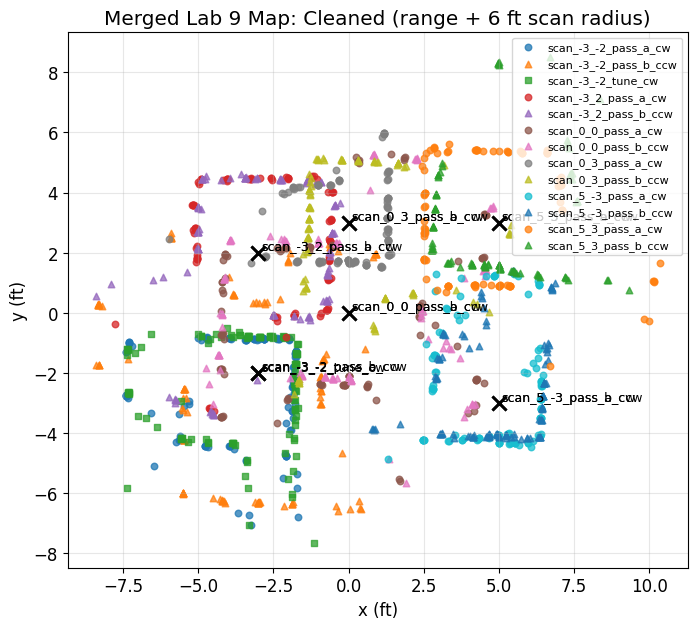

,scan_name,raw_points,clean_points
0,scan_-3_-2_pass_a_cw,127,121
1,scan_-3_-2_pass_b_ccw,127,112
2,scan_-3_-2_tune_cw,127,120
3,scan_-3_2_pass_a_cw,127,101
4,scan_-3_2_pass_b_ccw,127,107
5,scan_0_0_pass_a_cw,127,110
6,scan_0_0_pass_b_ccw,127,110
7,scan_0_3_pass_a_cw,127,113
8,scan_0_3_pass_b_ccw,127,99
9,scan_5_-3_pass_a_cw,127,120


,scan_name,sensor,x_ft,y_ft,heading_deg,range_ft,pass_name
0,scan_-3_-2_tune_cw,right,-1.753285,-4.774066,24.2,3.041339,tune_cw
1,scan_-3_-2_tune_cw,right,-2.131574,-4.656953,18.1,2.795276,tune_cw
2,scan_-3_-2_tune_cw,right,-1.843308,-5.248367,19.6,3.448163,tune_cw
3,scan_-3_-2_tune_cw,right,-1.776822,-3.746879,35.0,2.132546,tune_cw
4,scan_-3_-2_tune_cw,right,-1.969850,-4.030536,26.9,2.276903,tune_cw


In [17]:
def rot2(theta_deg):
    th = np.deg2rad(theta_deg)
    c, s = np.cos(th), np.sin(th)
    return np.array([[c, -s], [s, c]])

def sensor_hits_room(df, pose, sensor='front'):
    if sensor == 'front':
        valid = df['front_valid']
        ranges_ft = df.loc[valid, 'front_ft'].to_numpy()
        headings_deg = df.loc[valid, 'heading_deg'].to_numpy()
        sensor_offset = FRONT_SENSOR_OFFSET_FT
        sensor_yaw_deg = FRONT_SENSOR_YAW_DEG
    elif sensor == 'right':
        valid = df['right_valid']
        ranges_ft = df.loc[valid, 'right_ft'].to_numpy()
        headings_deg = df.loc[valid, 'heading_deg'].to_numpy()
        sensor_offset = RIGHT_SENSOR_OFFSET_FT
        sensor_yaw_deg = RIGHT_SENSOR_YAW_DEG
    else:
        raise ValueError('sensor must be front or right')

    if len(ranges_ft) == 0:
        return pd.DataFrame(columns=['scan_name', 'sensor', 'x_ft', 'y_ft', 'heading_deg', 'range_ft'])

    rows = []
    room_origin = np.array([pose['x_ft'] + pose.get('dx_ft', 0.0),
                            pose['y_ft'] + pose.get('dy_ft', 0.0)])
    theta0_corr = pose['theta0_deg'] + pose.get('dtheta_deg', 0.0)
    for heading_deg, rng_ft in zip(headings_deg, ranges_ft):
        body_to_room = rot2(theta0_corr + heading_deg + ROBOT_YAW_OFFSET_DEG)
        ray_body = np.array([
            np.cos(np.deg2rad(sensor_yaw_deg)),
            np.sin(np.deg2rad(sensor_yaw_deg)),
        ]) * rng_ft
        hit_room = room_origin + body_to_room @ (sensor_offset + ray_body)
        rows.append({
            'scan_name': df['scan_name'].iloc[0],
            'sensor': sensor,
            'x_ft': hit_room[0],
            'y_ft': hit_room[1],
            'heading_deg': heading_deg,
            'range_ft': rng_ft,
            'pass_name': df['pass_name'].iloc[0],
        })
    return pd.DataFrame(rows)

def build_global_points(scan_runs, sensor=ACTIVE_SENSOR):
    chunks = []
    for name, entry in scan_runs.items():
        df = entry['df']
        pose = entry['pose']
        if df.empty:
            continue
        chunks.append(sensor_hits_room(df, pose, sensor=sensor))
    if not chunks:
        return pd.DataFrame(columns=['scan_name', 'sensor', 'x_ft', 'y_ft'])
    return pd.concat(chunks, ignore_index=True)

def filter_points_by_range(points_df, min_range_ft=MIN_VALID_RANGE_FT,
                           max_range_ft=MAX_VALID_RANGE_FT):
    if points_df.empty:
        return points_df.copy()

    keep_mask = points_df['range_ft'].between(min_range_ft, max_range_ft, inclusive='both')
    filtered = points_df.loc[keep_mask].copy().reset_index(drop=True)
    removed = int((~keep_mask).sum())
    print(f'Range filter: kept {len(filtered)}/{len(points_df)} points, removed {removed}')
    return filtered

def filter_isolated_points(points_df, radius_ft=OUTLIER_RADIUS_FT,
                           min_neighbors=OUTLIER_MIN_NEIGHBORS):
    if points_df.empty:
        return points_df.copy()
    if len(points_df) <= min_neighbors:
        return points_df.copy()

    xy = points_df[['x_ft', 'y_ft']].to_numpy(dtype=float)
    diffs = xy[:, None, :] - xy[None, :, :]
    dist2 = np.sum(diffs * diffs, axis=2)
    neighbor_counts = (dist2 <= radius_ft ** 2).sum(axis=1) - 1
    keep_mask = neighbor_counts >= min_neighbors

    filtered = points_df.loc[keep_mask].copy().reset_index(drop=True)
    removed = int((~keep_mask).sum())
    print(f'Optional isolated-point filter: kept {len(filtered)}/{len(points_df)} points, removed {removed}')
    return filtered

def plot_single_run_cartesian(run_name, sensor=ACTIVE_SENSOR):
    if run_name not in scan_runs:
        print(f'Unknown run: {run_name}')
        return pd.DataFrame()

    entry = scan_runs[run_name]
    pts = sensor_hits_room(entry['df'], entry['pose'], sensor=sensor)
    if pts.empty:
        print(f'No valid points for {run_name}')
        return pts

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(pts['x_ft'], pts['y_ft'], s=20, alpha=0.8, label=run_name)
    pose = entry['pose']
    x0 = pose['x_ft'] + pose.get('dx_ft', 0.0)
    y0 = pose['y_ft'] + pose.get('dy_ft', 0.0)
    ax.plot(x0, y0, 'kx', ms=10, mew=2)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('x (ft)')
    ax.set_ylabel('y (ft)')
    ax.set_title(f'Cartesian Map: {run_name}')
    ax.grid(alpha=0.3)
    ax.legend()
    plt.show()
    return pts

def filter_points_by_scan_radius(points_df, scan_runs, max_dist_ft=MAX_POINTS_FROM_SCAN_FT):
    if points_df.empty:
        return points_df.copy()

    keep = []
    for _, row in points_df.iterrows():
        pose = scan_runs[row['scan_name']]['pose']
        x0 = pose['x_ft'] + pose.get('dx_ft', 0.0)
        y0 = pose['y_ft'] + pose.get('dy_ft', 0.0)
        d = np.hypot(row['x_ft'] - x0, row['y_ft'] - y0)
        keep.append(d <= max_dist_ft)

    keep_mask = np.array(keep, dtype=bool)
    filtered = points_df.loc[keep_mask].copy().reset_index(drop=True)
    removed = int((~keep_mask).sum())
    print(f'Scan-radius filter ({max_dist_ft:.1f} ft): kept {len(filtered)}/{len(points_df)} points, removed {removed}')
    return filtered

def summarize_point_counts(raw_points, clean_points):
    raw_counts = raw_points.groupby('scan_name').size().rename('raw_points') if not raw_points.empty else pd.Series(dtype=int)
    clean_counts = clean_points.groupby('scan_name').size().rename('clean_points') if not clean_points.empty else pd.Series(dtype=int)
    summary = pd.concat([raw_counts, clean_counts], axis=1).fillna(0).astype(int).reset_index()
    return summary.rename(columns={'index': 'scan_name'})

def plot_global_points(points_df, show_scan_origins=True, title='Merged Lab 9 Map in Room Frame'):
    if points_df.empty:
        print('No global points to plot.')
        return

    fig, ax = plt.subplots(figsize=(8, 8))
    markers = {'pass_a_cw': 'o', 'pass_b_ccw': '^', 'tune_cw': 's'}
    for scan_name, group in points_df.groupby('scan_name'):
        pass_name = group['pass_name'].iloc[0] if 'pass_name' in group else 'pass'
        marker = markers.get(pass_name, 'o')
        ax.scatter(group['x_ft'], group['y_ft'], s=22, alpha=0.75,
                   marker=marker, label=scan_name)

    if show_scan_origins:
        for name, entry in scan_runs.items():
            pose = entry['pose']
            x0 = pose['x_ft'] + pose.get('dx_ft', 0.0)
            y0 = pose['y_ft'] + pose.get('dy_ft', 0.0)
            ax.plot(x0, y0, 'kx', ms=10, mew=2)
            ax.text(x0 + 0.08, y0 + 0.08, name, fontsize=9)

    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('x (ft)')
    ax.set_ylabel('y (ft)')
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    plt.show()

def plot_scan_group(scan_key, use_clean=False, sensor=ACTIVE_SENSOR):
    names = [name for name in scan_runs if name.startswith(f'{scan_key}_')]
    if not names:
        print(f'No runs found for {scan_key}')
        return pd.DataFrame()

    chunks = []
    for name in names:
        entry = scan_runs[name]
        pts = sensor_hits_room(entry['df'], entry['pose'], sensor=sensor)
        if not pts.empty:
            chunks.append(pts)
    if not chunks:
        print(f'No valid points for {scan_key}')
        return pd.DataFrame()

    pts = pd.concat(chunks, ignore_index=True)
    pts = filter_points_by_range(pts)
    if use_clean:
        pts = filter_points_by_scan_radius(pts, scan_runs)

    fig, ax = plt.subplots(figsize=(7, 7))
    markers = {'pass_a_cw': 'o', 'pass_b_ccw': '^', 'tune_cw': 's'}
    for run_name, group in pts.groupby('scan_name'):
        pass_name = group['pass_name'].iloc[0]
        ax.scatter(group['x_ft'], group['y_ft'], s=24, alpha=0.8,
                   marker=markers.get(pass_name, 'o'), label=run_name)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('x (ft)')
    ax.set_ylabel('y (ft)')
    ax.set_title(f'{scan_key}: pass overlap ({"clean" if use_clean else "range-only"})')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    plt.show()
    return pts

global_points_raw = build_global_points(scan_runs, sensor=ACTIVE_SENSOR)
global_points_range = filter_points_by_range(global_points_raw)
global_points = filter_points_by_scan_radius(global_points_range, scan_runs)
plot_global_points(global_points_raw, title='Merged Lab 9 Map: Raw Global Points')
plot_global_points(global_points, title='Merged Lab 9 Map: Cleaned (range + 6 ft scan radius)')
point_count_summary = summarize_point_counts(global_points_raw, global_points)
display(point_count_summary)
global_points.head()


## 12. Map Inspection Helpers

Use these examples to inspect single runs, compare CW/CCW overlap at one location, and review the cleaned fused map before drawing walls.

In [18]:
# Examples:
# plot_single_run_cartesian('scan_-3_-2_pass_a_cw')
# plot_scan_group('scan_-3_-2', use_clean=False)
# plot_scan_group('scan_-3_-2', use_clean=True)
# plot_global_points(global_points_raw, title='Raw Global Map')
# plot_global_points(global_points, title='Cleaned Global Map')
# point_count_summary


## 13. Wall Fitting / Line Map

Use the cleaned global point cloud to manually estimate wall and obstacle segments. This section overlays hand-drawn line segments on top of the scatter map and exports simulator-ready endpoint lists.

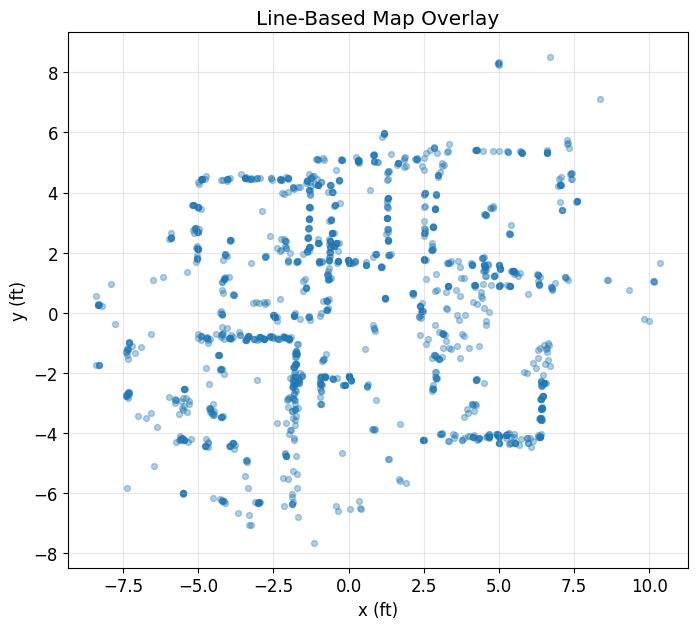

line_starts = []
line_ends   = []
x_starts = []
y_starts = []
x_ends   = []
y_ends   = []


{'line_starts': [],
 'line_ends': [],
 'x_starts': [],
 'y_starts': [],
 'x_ends': [],
 'y_ends': []}

In [19]:
# Fill these in after you inspect the cleaned global map.
# Example format:
# line_starts = [(x1, y1), (x2, y2)]
# line_ends   = [(x1b, y1b), (x2b, y2b)]

line_starts = []
line_ends = []

def plot_wall_lines(points_df, line_starts, line_ends, show_labels=True):
    fig, ax = plt.subplots(figsize=(8, 8))
    if not points_df.empty:
        ax.scatter(points_df['x_ft'], points_df['y_ft'], s=18, alpha=0.35, color='tab:blue')

    for idx, ((x0, y0), (x1, y1)) in enumerate(zip(line_starts, line_ends), start=1):
        ax.plot([x0, x1], [y0, y1], 'r-', lw=2.5)
        if show_labels:
            xm = 0.5 * (x0 + x1)
            ym = 0.5 * (y0 + y1)
            ax.text(xm, ym, str(idx), color='darkred', fontsize=10)

    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('x (ft)')
    ax.set_ylabel('y (ft)')
    ax.set_title('Line-Based Map Overlay')
    ax.grid(alpha=0.3)
    plt.show()

def export_line_map(line_starts, line_ends):
    xs = [p[0] for p in line_starts]
    ys = [p[1] for p in line_starts]
    xe = [p[0] for p in line_ends]
    ye = [p[1] for p in line_ends]
    print('line_starts =', line_starts)
    print('line_ends   =', line_ends)
    print('x_starts =', xs)
    print('y_starts =', ys)
    print('x_ends   =', xe)
    print('y_ends   =', ye)
    return {
        'line_starts': line_starts,
        'line_ends': line_ends,
        'x_starts': xs,
        'y_starts': ys,
        'x_ends': xe,
        'y_ends': ye,
    }

plot_wall_lines(global_points, line_starts, line_ends, show_labels=True)
line_map_export = export_line_map(line_starts, line_ends)
line_map_export


## 14. Disconnect

In [20]:
# Run this when you are done.
# ble.disconnect()
# print('Disconnected from Artemis.')
